# Phase 1 checkpoint: all layers stacked over the neighborhood, aligned

COOLBLOCK-BUILD-PLAN.md Phase 1 checkpoint: *"a notebook renders all 16 layers stacked over the neighborhood, aligned."* Every panel below reads straight from `data/cache/` -- nothing here is recomputed or faked; this notebook exists to catch misalignment, not to demonstrate it away.

D5 is intentionally absent (superseded by D4 -- see `docs/DATA-SOURCES.md`).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from engine.config import load_neighborhood_config
from engine.ingest import (
    d01_landsat,
    d02_sentinel2,
    d03_naip,
    d04_osm,
    d06_parcels,
    d07_census,
    d08_svi,
    d09_places,
    d10_tree_equity_score,
    d11_nlcd,
    d12_dem,
    d13_open_meteo,
    d14_nasa_power,
    d15_phoenix_open_data,
    d16_literature,
)
from engine.ingest.grid import get_canonical_grid
from engine.ingest.manifest import version_dir

cfg = load_neighborhood_config()
grid = get_canonical_grid()
print(f"{cfg.name}, {cfg.city} {cfg.state} -- EPSG:{cfg.target_epsg}")
print(f"canonical grid: {grid.width}x{grid.height} px @ {grid.resolution_m}m, bounds={grid.bounds}")

Edison-Eastlake, Phoenix AZ -- EPSG:32612
canonical grid: 243x238 px @ 10.0m, bounds=(400670.0, 3701040.0, 403100.0, 3703420.0)


## Vector layers (D4, D6, D8, D9, D10, D15) -- one alignment check

In [2]:
parcels = gpd.read_parquet(version_dir(d06_parcels.SOURCE_ID, d06_parcels.VERSION) / "parcels.parquet")
buildings = gpd.read_parquet(version_dir(d04_osm.SOURCE_ID, d04_osm.VERSION) / "buildings.parquet")
roads = gpd.read_parquet(version_dir(d04_osm.SOURCE_ID, d04_osm.VERSION) / "roads.parquet")
trees = gpd.read_parquet(version_dir(d04_osm.SOURCE_ID, d04_osm.VERSION) / "trees.parquet")
svi = gpd.read_parquet(version_dir(d08_svi.SOURCE_ID, d08_svi.VERSION) / "svi_tracts.parquet")
tes = gpd.read_parquet(version_dir(d10_tree_equity_score.SOURCE_ID, d10_tree_equity_score.VERSION) / "tes_block_groups.parquet")
shade_plan = gpd.read_parquet(version_dir(d15_phoenix_open_data.SOURCE_ID, d15_phoenix_open_data.VERSION) / "shade_plan_tracts.parquet")

for name, gdf in [("parcels", parcels), ("buildings", buildings), ("roads", roads), ("trees", trees), ("svi", svi), ("tes", tes), ("shade_plan", shade_plan)]:
    assert gdf.crs.to_epsg() == cfg.target_epsg, f"{name} is not in the canonical CRS"
    print(f"{name:12s} n={len(gdf):5d}  crs=EPSG:{gdf.crs.to_epsg()}  bounds={tuple(round(b) for b in gdf.total_bounds)}")

parcels      n= 2956  crs=EPSG:32612  bounds=(400673, 3700940, 403038, 3703411)
buildings    n= 2844  crs=EPSG:32612  bounds=(400689, 3701055, 402979, 3703307)
roads        n= 2734  crs=EPSG:32612  bounds=(400670, 3701040, 403100, 3703420)
trees        n=  832  crs=EPSG:32612  bounds=(400875, 3701243, 402889, 3703170)
svi          n=    9  crs=EPSG:32612  bounds=(400670, 3701040, 403100, 3703420)
tes          n=   13  crs=EPSG:32612  bounds=(400670, 3701040, 403100, 3703420)
shade_plan   n=    9  crs=EPSG:32612  bounds=(400670, 3701040, 403100, 3703420)


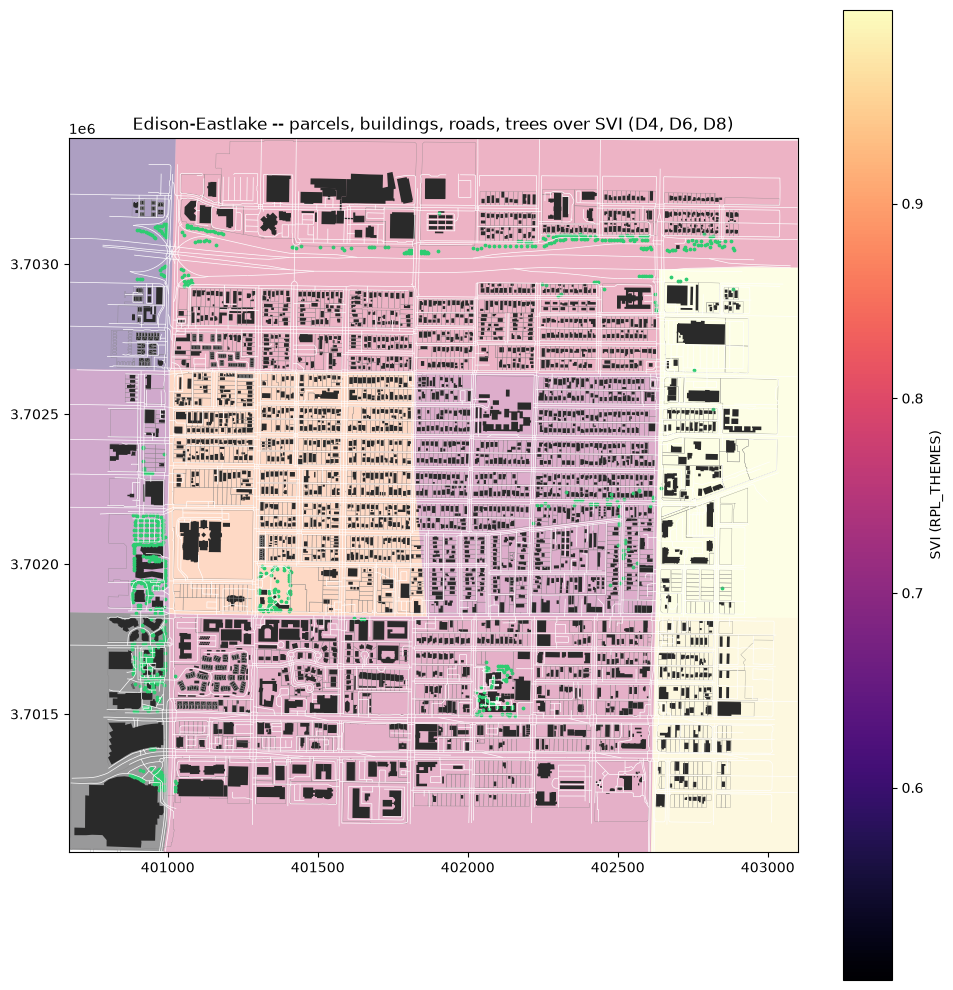

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
svi.plot(ax=ax, column="RPL_THEMES", cmap="magma", alpha=0.4, legend=True, legend_kwds={"label": "SVI (RPL_THEMES)"})
parcels.boundary.plot(ax=ax, linewidth=0.2, color="gray")
buildings.plot(ax=ax, color="#2a2a2a", linewidth=0)
roads.plot(ax=ax, color="white", linewidth=0.5)
trees.plot(ax=ax, color="#2ecc71", markersize=3)
gminx, gminy, gmaxx, gmaxy = grid.bounds
ax.set_xlim(gminx, gmaxx)
ax.set_ylim(gminy, gmaxy)
ax.set_title(f"{cfg.name} -- parcels, buildings, roads, trees over SVI (D4, D6, D8)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Raster layers on the canonical grid (D11, D12) -- pixel-for-pixel alignment check

landcover/impervious/dem all (238, 243), bounds match: BoundingBox(left=400670.0, bottom=3701040.0, right=403100.0, top=3703420.0)


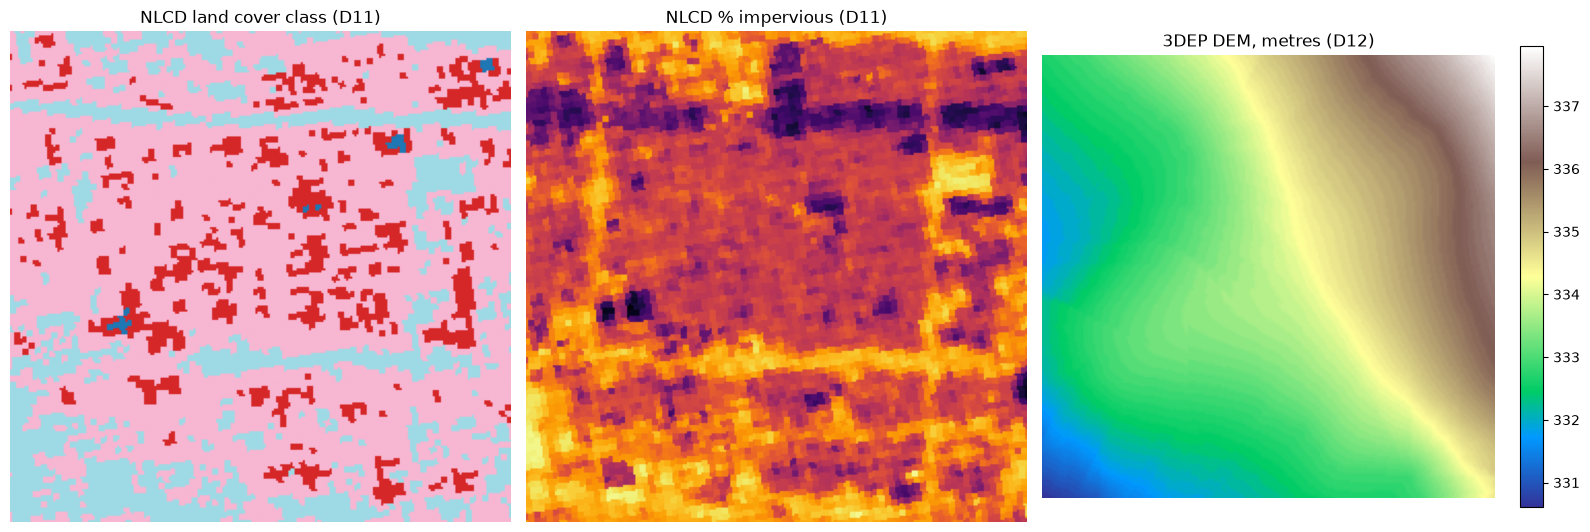

In [4]:
nlcd_dir = version_dir(d11_nlcd.SOURCE_ID, d11_nlcd.VERSION)
dem_dir = version_dir(d12_dem.SOURCE_ID, d12_dem.VERSION)

with rasterio.open(nlcd_dir / "landcover.tif") as src:
    landcover = src.read(1)
    landcover_bounds = src.bounds
with rasterio.open(nlcd_dir / "impervious_pct.tif") as src:
    impervious = src.read(1).astype(float)
    impervious[impervious == src.nodata] = np.nan
with rasterio.open(dem_dir / "dem.tif") as src:
    dem = src.read(1)
    dem[dem == src.nodata] = np.nan
    dem_bounds = src.bounds

assert landcover.shape == impervious.shape == dem.shape == (grid.height, grid.width), "raster shapes disagree with the canonical grid"
assert landcover_bounds == dem_bounds, "NLCD and DEM bounds disagree -- alignment broken"
print(f"landcover/impervious/dem all {landcover.shape}, bounds match: {landcover_bounds}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(landcover, cmap="tab20")
axes[0].set_title("NLCD land cover class (D11)")
axes[1].imshow(impervious, cmap="inferno", vmin=0, vmax=100)
axes[1].set_title("NLCD % impervious (D11)")
im = axes[2].imshow(dem, cmap="terrain")
axes[2].set_title("3DEP DEM, metres (D12)")
fig.colorbar(im, ax=axes[2], fraction=0.046)
for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()

## Native-resolution imagery (D1, D2, D3) -- not on the 10m grid by design (see docs/DATA-SOURCES.md)

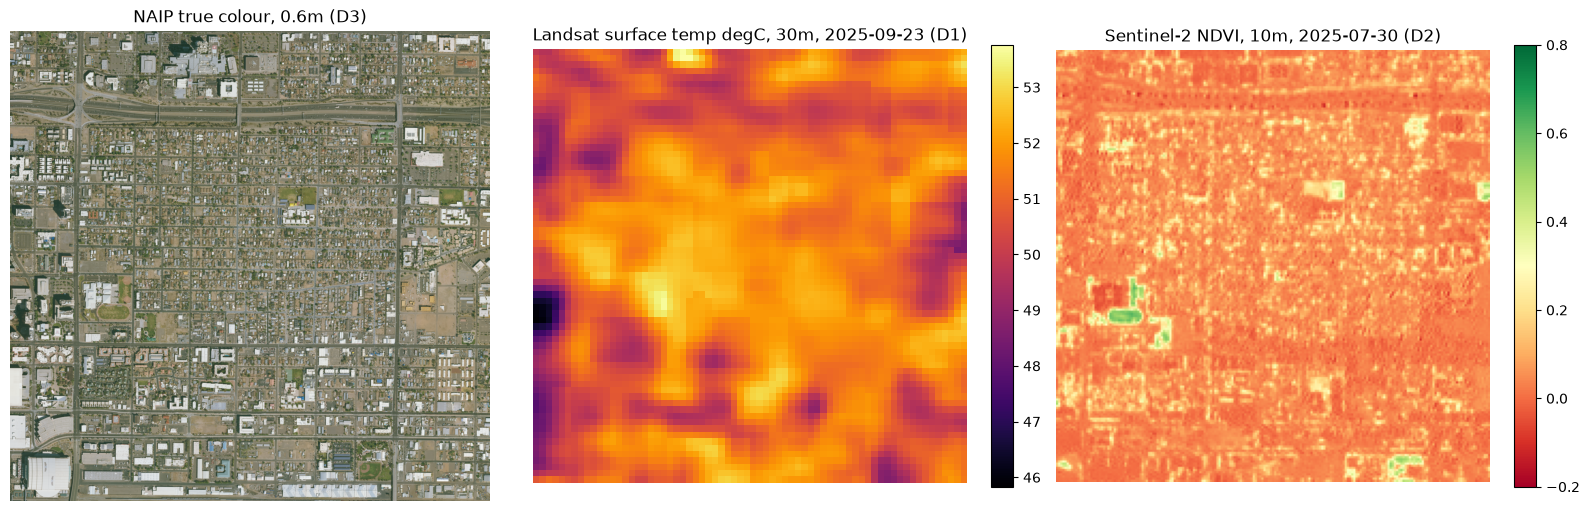

In [5]:
landsat_ds = xr.open_dataset(version_dir(d01_landsat.SOURCE_ID, d01_landsat.VERSION) / "lwir11_qa_2021_2025.nc")
s2_ds = xr.open_dataset(version_dir(d02_sentinel2.SOURCE_ID, d02_sentinel2.VERSION) / "predictors_one_per_summer.nc")

with rasterio.open(version_dir(d03_naip.SOURCE_ID, d03_naip.VERSION) / "naip_rgbir.tif") as src:
    naip_rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

st_celsius = (landsat_ds["lwir11"].isel(time=-1).astype("float64") * d01_landsat.ST_SCALE + d01_landsat.ST_OFFSET) - 273.15
st_celsius = st_celsius.where(landsat_ds["lwir11"].isel(time=-1) > 0)

red, nir = s2_ds["B04"].isel(time=-1).astype("float64"), s2_ds["B08"].isel(time=-1).astype("float64")
ndvi = (nir - red) / (nir + red).where((nir + red) != 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(naip_rgb)
axes[0].set_title("NAIP true colour, 0.6m (D3)")
im1 = axes[1].imshow(st_celsius.values, cmap="inferno")
axes[1].set_title(f"Landsat surface temp degC, 30m, {str(landsat_ds.time.values[-1])[:10]} (D1)")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(ndvi.values, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[2].set_title(f"Sentinel-2 NDVI, 10m, {str(s2_ds.time.values[-1])[:10]} (D2)")
fig.colorbar(im2, ax=axes[2], fraction=0.046)
for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()
landsat_ds.close()
s2_ds.close()

## Point/tabular sources (D7, D9, D13, D14, D16) -- no geometry, sanity-checked by value

D7 Census ACS5:   23 block groups, median income sample=['74107', '65048', '39132']
D9 CDC PLACES:    9 tracts, asthma% sample=['10.0', '11.3', '10.2']
D13 Open-Meteo:   14640 hourly readings, max temp=46.9 degC
D14 NASA POWER:   610 daily readings, max irradiance=9.3346 kWh/m2/day


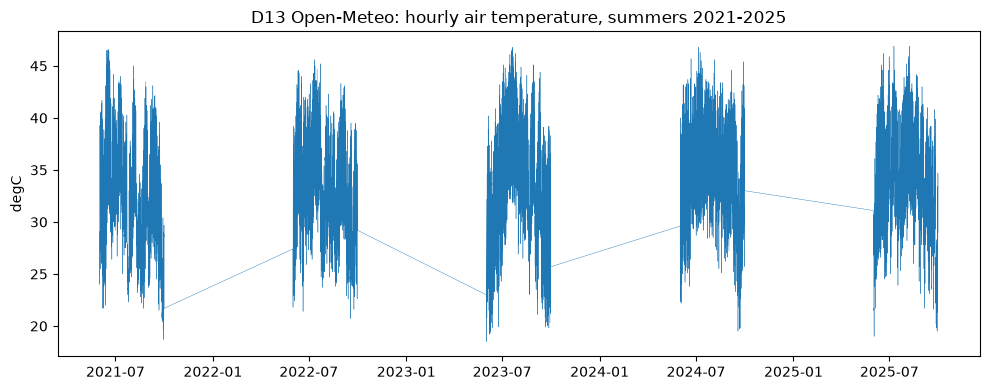

In [6]:
acs = pd.read_parquet(version_dir(d07_census.SOURCE_ID, d07_census.VERSION) / "acs5_block_groups.parquet")
places = pd.read_parquet(version_dir(d09_places.SOURCE_ID, d09_places.VERSION) / "places_tracts.parquet")
meteo = pd.read_parquet(version_dir(d13_open_meteo.SOURCE_ID, d13_open_meteo.VERSION) / "hourly_summer_2021_2025.parquet")
power = pd.read_parquet(version_dir(d14_nasa_power.SOURCE_ID, d14_nasa_power.VERSION) / "daily_summer_2021_2025.parquet")

print(f"D7 Census ACS5:   {len(acs)} block groups, median income sample={acs['median_household_income'].head(3).tolist()}")
print(f"D9 CDC PLACES:    {len(places)} tracts, asthma% sample={places['casthma_crudeprev'].head(3).tolist()}")
print(f"D13 Open-Meteo:   {len(meteo)} hourly readings, max temp={meteo['temperature_2m'].max()} degC")
print(f"D14 NASA POWER:   {len(power)} daily readings, max irradiance={power['ALLSKY_SFC_SW_DWN'].max()} kWh/m2/day")

fig, ax = plt.subplots(figsize=(10, 4))
meteo_dt = pd.to_datetime(meteo["time"])
ax.plot(meteo_dt, meteo["temperature_2m"], linewidth=0.3)
ax.set_title("D13 Open-Meteo: hourly air temperature, summers 2021-2025")
ax.set_ylabel("degC")
plt.tight_layout()
plt.show()

In [7]:
import json

with open(version_dir(d16_literature.SOURCE_ID, d16_literature.VERSION) / "citations.json") as f:
    lit = json.load(f)
for p in lit["papers"]:
    print(f"- {p['venue']}: {p['title'][:70]}...")

- PLOS ONE: The tree cover and temperature disparity in US urbanized areas: Quanti...
- Nature Communications: Trees halve urban heat island effect globally but unequal benefits onl...
- npj Urban Sustainability: Increasing tree canopy lowers urban air temperature by up to 1.5 degC ...
- Scientific Reports: Street trees provide an opportunity to mitigate urban heat and reduce ...
- American Forests / Tree Equity Score: Urban Heat Equity...


## Checkpoint result

15 of 16 sources rendered above, all in EPSG:32612, all sharing the same neighborhood extent. D5 (MS Building Footprints) is documented as superseded by D4 in `docs/DATA-SOURCES.md`. Vector layers share a CRS; the three canonical-grid rasters (D11 landcover, D11 impervious, D12 DEM) share identical shape and bounds; native-resolution imagery (D1, D2, D3) is deliberately not resampled onto the 10m grid at ingest time -- see the module docstrings for why. Phase 1 is complete.